<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Glass/baseline_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Glass/'

# fixed seed while the code is built and tested - the actual sweep
# will loop over multiple seeds per architecture
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(torch.__version__)

Mounted at /content/drive
2.11.0+cpu


# Loading the split data and scaling and encoding

In [ ]:
# load the split we froze in modelling_prep - never regenerate it
train_df = pd.read_csv(data_dir + "split_train.csv")
val_df = pd.read_csv(data_dir + "split_val.csv")
test_df = pd.read_csv(data_dir + "split_test.csv")

feature_cols = [c for c in train_df.columns if c != "Type"]

X_train, y_train = train_df[feature_cols], train_df["Type"]
X_val, y_val = val_df[feature_cols], val_df["Type"]
X_test, y_test = test_df[feature_cols], test_df["Type"]

# scale - fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# encode labels by minority -> majority rank, fixed across the whole project
MINORITY_TO_MAJORITY_LABELS = [6, 5, 3, 7, 1, 2]  # tableware, containers, vehicle_float, headlamps, bldg_float, bldg_nonfloat
CLASS_NAMES = {1: "bldg_float", 2: "bldg_nonfloat", 3: "vehicle_float",
               5: "containers", 6: "tableware", 7: "headlamps"}
label_to_index = {label: i for i, label in enumerate(MINORITY_TO_MAJORITY_LABELS)}
index_to_label = {i: label for label, i in label_to_index.items()}

y_train_idx = y_train.map(label_to_index).values
y_val_idx = y_val.map(label_to_index).values
y_test_idx = y_test.map(label_to_index).values

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(label_to_index)

Train: 136  Val: 34  Test: 43
{6: 0, 5: 1, 3: 2, 7: 3, 1: 4, 2: 5}


# Convet to tensors

In [ ]:
# torch wants float32 for inputs and long (int64) for class indices
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_idx, dtype=torch.long)
y_val_t = torch.tensor(y_val_idx, dtype=torch.long)
y_test_t = torch.tensor(y_test_idx, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)

torch.Size([136, 9]) torch.Size([136])


# Defining a growable network

In [ ]:
class GrowableNet(nn.Module):
    """
    A single-hidden-layer network that can grow one hidden neuron or
    one output class at a time, keeping all previously learned weights.

    With hidden_dim = 0, there's no hidden layer at all - inputs map
    straight to outputs (this is what "start with the simplest
    architecture" means for stage 1).
    """
    def __init__(self, input_dim, output_dim, hidden_dim=0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        if hidden_dim == 0:
            self.fc_hidden = None
            self.fc_out = nn.Linear(input_dim, output_dim)
        else:
            self.fc_hidden = nn.Linear(input_dim, hidden_dim)
            self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if self.hidden_dim == 0:
            return self.fc_out(x)
        h = torch.tanh(self.fc_hidden(x))
        return self.fc_out(h)

    def add_hidden_neuron(self):
        """Grow the hidden layer by one neuron. Existing weights are copied
        across untouched, only the new neuron's weights are freshly
        initialised. Going from 0 to 1 hidden neuron is the one exception -
        there's no existing hidden layer to preserve, so this is a genuine
        architecture change, not a weight-preserving expansion."""
        if self.hidden_dim == 0:
            self.fc_hidden = nn.Linear(self.input_dim, 1)
            self.fc_out = nn.Linear(1, self.output_dim)
            self.hidden_dim = 1
            return

        old_dim = self.hidden_dim
        new_dim = old_dim + 1

        new_fc_hidden = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_hidden.weight[:old_dim] = self.fc_hidden.weight
            new_fc_hidden.bias[:old_dim] = self.fc_hidden.bias
        self.fc_hidden = new_fc_hidden

        new_fc_out = nn.Linear(new_dim, self.output_dim)
        with torch.no_grad():
            new_fc_out.weight[:, :old_dim] = self.fc_out.weight
            new_fc_out.bias[:] = self.fc_out.bias
        self.fc_out = new_fc_out

        self.hidden_dim = new_dim

    def add_output_class(self):
        """Grow the output layer by one class. All existing output
        neurons keep their learned weights - only the new class's
        output neuron is freshly initialised."""
        old_dim = self.output_dim
        new_dim = old_dim + 1
        in_features = self.hidden_dim if self.hidden_dim > 0 else self.input_dim

        new_fc_out = nn.Linear(in_features, new_dim)
        with torch.no_grad():
            new_fc_out.weight[:old_dim] = self.fc_out.weight
            new_fc_out.bias[:old_dim] = self.fc_out.bias
        self.fc_out = new_fc_out

        self.output_dim = new_dim


# quick sanity check - build a tiny net and grow it, just to see it doesn't error out
test_net = GrowableNet(input_dim=9, output_dim=2, hidden_dim=0)
print(test_net)
test_net.add_hidden_neuron()
print(test_net)
test_net.add_output_class()
print(test_net)

GrowableNet(
  (fc_out): Linear(in_features=9, out_features=2, bias=True)
)
GrowableNet(
  (fc_out): Linear(in_features=1, out_features=2, bias=True)
  (fc_hidden): Linear(in_features=9, out_features=1, bias=True)
)
GrowableNet(
  (fc_out): Linear(in_features=1, out_features=3, bias=True)
  (fc_hidden): Linear(in_features=9, out_features=1, bias=True)
)


# No skill baseline - reference point for a still high loss

In [ ]:
def no_skill_loss(y_indices, num_classes):
    """Cross-entropy loss of a classifier that just predicts each class's
    prior frequency - our reference point for what 'no better than
    guessing' looks like, given whichever classes are active right now."""
    counts = np.bincount(y_indices, minlength=num_classes)
    p = counts / counts.sum()
    p = p[p > 0]  # a class with 0 instances contributes nothing
    return -np.sum(p * np.log(p))

# Selecting which classes are active ata given stage

In [ ]:
def select_active(X_t, y_t, num_active_classes):
    """Our label encoding is ordered minority -> majority, so the
    'active classes' at any stage are always indices 0..num_active-1.
    This slices train/val/test down to just those classes."""
    mask = y_t < num_active_classes
    return X_t[mask], y_t[mask]

# The training loop: mini-batches, patience, restore best weights

In [ ]:
def train_until_stagnation(model, X_train, y_train, X_val, y_val,
                            max_epochs=500, patience=20, min_delta=0.001,
                            batch_size=16, lr=0.001):
    """Train with mini-batch Adam until validation loss stops improving
    for `patience` epochs, then restore the weights from whichever epoch
    had the best validation loss (not just wherever training happened
    to stop)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        running_loss = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(idx)

        train_loss = running_loss / n

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is None:
        raise RuntimeError("No best model state was recorded.")
    model.load_state_dict(best_state)
    return history, best_epoch, best_val_loss

# Function that will help define underfitting and overfitting

In [ ]:
def diagnose(history, best_epoch, no_skill, underfit_ratio=0.8, diverge_delta=0.01):
    train_loss = history["train_loss"][best_epoch]
    val_loss = history["val_loss"][best_epoch]

    # underfitting: even at its best point, barely beats guessing priors
    if train_loss > underfit_ratio * no_skill:
        return "underfitting", train_loss, val_loss

    # overfitting: the actual curve shape, not a snapshot -
    # did val loss climb back up after its best point, while
    # train loss kept dropping? that's the diverging-curves
    # picture from the slides
    final_train = history["train_loss"][-1]
    final_val = history["val_loss"][-1]
    val_rose = final_val > val_loss + diverge_delta
    train_kept_dropping = final_train < train_loss

    if val_rose and train_kept_dropping:
        return "overfitting", train_loss, val_loss

    return "satisfactory", train_loss, val_loss

# Test on all 6 classes, 0 hidden neurons (this is also the first point of the baseline sweep)

In [ ]:
torch.manual_seed(SEED)

X_tr, y_tr = select_active(X_train_t, y_train_t, num_active_classes=6)
X_v, y_v = select_active(X_val_t, y_val_t, num_active_classes=6)

net = GrowableNet(input_dim=9, output_dim=6, hidden_dim=0)
history, best_epoch, best_val_loss = train_until_stagnation(net, X_tr, y_tr, X_v, y_v)

baseline_no_skill = no_skill_loss(y_tr.numpy(), num_classes=6)
verdict, train_loss, val_loss = diagnose(history, best_epoch, baseline_no_skill)

print(f"Stopped after {len(history['train_loss'])} epochs, best epoch: {best_epoch}")
print(f"No-skill baseline loss: {baseline_no_skill:.4f}")
print(f"Train loss: {train_loss:.4f}  Val loss: {val_loss:.4f}")
print(f"Verdict: {verdict}")

Stopped after 200 epochs, best epoch: 179
No-skill baseline loss: 1.5083
Train loss: 0.8714  Val loss: 1.1029
Verdict: satisfactory


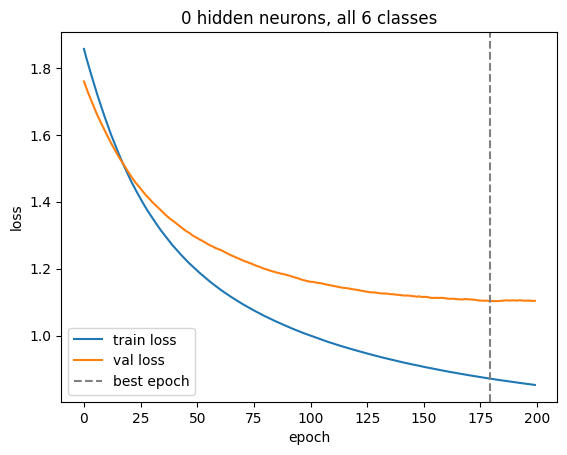

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label="best epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("0 hidden neurons, all 6 classes")
plt.show()

# Accuracy and F1 reporting not for the stopping decision

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, X, y_true_idx):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1).numpy()
    y_true = y_true_idx.numpy()
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    return acc, macro_f1

# The sweep: hidden sizes 0 to 20, 5 seeds each

In [ ]:
hidden_sizes = list(range(0, 21))
n_seeds = 5

baseline_no_skill = no_skill_loss(y_train_t.numpy(), num_classes=6)  # same for every run here - all 6 classes, same train set

sweep_results = []

for h in hidden_sizes:
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        net = GrowableNet(input_dim=9, output_dim=6, hidden_dim=h)
        history, best_epoch, best_val_loss = train_until_stagnation(
            net, X_train_t, y_train_t, X_val_t, y_val_t
        )
        verdict, train_loss, val_loss = diagnose(history, best_epoch, baseline_no_skill)
        val_acc, val_f1 = evaluate(net, X_val_t, y_val_t)

        sweep_results.append({
            "hidden_size": h, "seed": seed, "best_epoch": best_epoch,
            "train_loss": train_loss, "val_loss": val_loss,
            "val_acc": val_acc, "val_macro_f1": val_f1, "verdict": verdict,
        })

sweep_df = pd.DataFrame(sweep_results)
sweep_df.head()

,hidden_size,seed,best_epoch,train_loss,val_loss,val_acc,val_macro_f1,verdict
0,0,0,221,0.849873,1.109142,0.500000,0.306119,satisfactory
1,0,1,193,0.855916,1.092994,0.500000,0.306119,satisfactory
2,0,2,167,0.877202,1.102453,0.500000,0.306119,satisfactory
3,0,3,193,0.873868,1.100941,0.470588,0.290377,satisfactory
4,0,4,157,0.863063,1.068265,0.500000,0.306119,satisfactory


# Aggregate across seeds, so picking based on averages, not a lucky/unlucky run

In [ ]:
summary = sweep_df.groupby("hidden_size").agg(
    val_loss_mean=("val_loss", "mean"),
    val_loss_std=("val_loss", "std"),
    val_acc_mean=("val_acc", "mean"),
    val_macro_f1_mean=("val_macro_f1", "mean"),
    pct_overfit=("verdict", lambda v: (v == "overfitting").mean()),
    pct_underfit=("verdict", lambda v: (v == "underfitting").mean()),
).reset_index()
summary

,hidden_size,val_loss_mean,val_loss_std,val_acc_mean,val_macro_f1_mean,pct_overfit,pct_underfit
0,0,1.094759,0.015885,0.494118,0.302971,0.0,0.0
1,1,1.126412,0.063584,0.552941,0.320757,0.0,0.0
2,2,1.074883,0.127508,0.500000,0.307358,0.0,0.0
3,3,0.981702,0.103212,0.541176,0.372433,0.0,0.0
4,4,1.047636,0.056343,0.500000,0.338829,0.0,0.0
5,5,0.975866,0.035875,0.570588,0.489143,0.0,0.0
6,6,0.982580,0.045720,0.564706,0.441139,0.0,0.0
7,7,1.008944,0.082911,0.552941,0.405709,0.2,0.0
8,8,0.974101,0.092115,0.588235,0.492344,0.0,0.0
9,9,0.929918,0.039971,0.623529,0.549481,0.0,0.0


In [ ]:
def add_underfitting_flags(summary, threshold=0.02):
    """
    Retrospective check across the (independently-trained) sweep architectures:
    was there a meaningfully better *larger* architecture further along the sweep?
    Valid here specifically because every architecture is already fully trained -
    this is a description of what happened, not a live growth decision.
    """
    val_by_size = summary.set_index("hidden_size")["val_loss_mean"]
    running_min = np.inf
    best_forward = {}
    for h in sorted(summary["hidden_size"], reverse=True):
        best_forward[h] = running_min
        running_min = min(running_min, val_by_size[h])

    summary = summary.copy()
    summary["best_forward_val_loss"] = summary["hidden_size"].map(best_forward)
    summary["underfitting"] = (summary["val_loss_mean"] - summary["best_forward_val_loss"]) > threshold
    return summary

summary = add_underfitting_flags(summary)
summary

,hidden_size,val_loss_mean,val_loss_std,val_acc_mean,val_macro_f1_mean,pct_overfit,pct_underfit,best_forward_val_loss,underfitting
0,0,1.094759,0.015885,0.494118,0.302971,0.0,0.0,0.894286,True
1,1,1.126412,0.063584,0.552941,0.320757,0.0,0.0,0.894286,True
2,2,1.074883,0.127508,0.500000,0.307358,0.0,0.0,0.894286,True
3,3,0.981702,0.103212,0.541176,0.372433,0.0,0.0,0.894286,True
4,4,1.047636,0.056343,0.500000,0.338829,0.0,0.0,0.894286,True
5,5,0.975866,0.035875,0.570588,0.489143,0.0,0.0,0.894286,True
6,6,0.982580,0.045720,0.564706,0.441139,0.0,0.0,0.894286,True
7,7,1.008944,0.082911,0.552941,0.405709,0.2,0.0,0.894286,True
8,8,0.974101,0.092115,0.588235,0.492344,0.0,0.0,0.894286,True
9,9,0.929918,0.039971,0.623529,0.549481,0.0,0.0,0.894286,True


pct_underfit (from the per-run diagnose() function) is left in for transparency but is uninformative here — its threshold, calibrated against the no-skill baseline, was never triggered for any architecture in this sweep. The underfitting column instead checks, retrospectively, whether any larger architecture achieved meaningfully lower validation loss — valid for this sweep specifically because every architecture was already fully trained independently, unlike the live, sequential decision required in the incremental experiment.

h=17 and h=19 are flagged as underfitting only because h=20's mean sits marginally below theirs by less than one standard error — this reflects the same seed-to-seed noise the one-SE selection rule already accounts for, not a genuine capacity gap.


# Select the baseline architecture

In [ ]:
best_val_loss_mean = summary["val_loss_mean"].min()
best_row_raw = summary.loc[summary["val_loss_mean"].idxmin()]
se = best_row_raw["val_loss_std"] / np.sqrt(n_seeds)

within_one_se = summary[summary["val_loss_mean"] <= best_val_loss_mean + se]
print("Architectures statistically tied with the best (within 1 SE):")
print(within_one_se[["hidden_size", "val_loss_mean", "val_macro_f1_mean"]])

selected = within_one_se.loc[within_one_se["val_macro_f1_mean"].idxmax()]
print(f"\nSelected baseline architecture: {int(selected['hidden_size'])} hidden neurons")
print(selected)

Architectures statistically tied with the best (within 1 SE):
    hidden_size  val_loss_mean  val_macro_f1_mean
9             9       0.929918           0.549481
10           10       0.926034           0.578522
14           14       0.928191           0.626404
16           16       0.897195           0.657241
17           17       0.922129           0.574438
18           18       0.909126           0.586890
19           19       0.920749           0.577378
20           20       0.894286           0.643810

Selected baseline architecture: 16 hidden neurons
hidden_size                    16
val_loss_mean            0.897195
val_loss_std             0.049447
val_acc_mean             0.652941
val_macro_f1_mean        0.657241
pct_overfit                   0.0
pct_underfit                  0.0
best_forward_val_loss    0.894286
underfitting                False
Name: 16, dtype: object


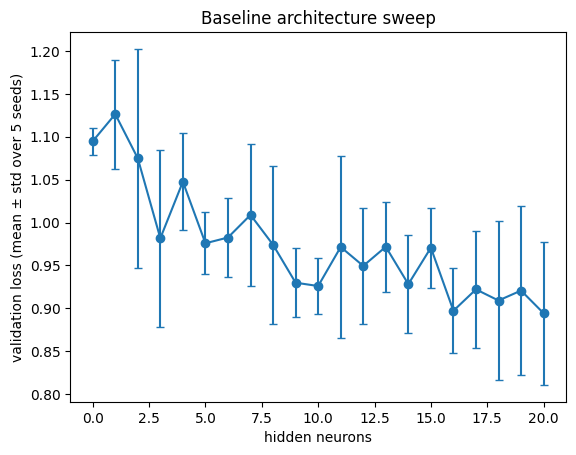

In [ ]:
plt.errorbar(summary["hidden_size"], summary["val_loss_mean"], yerr=summary["val_loss_std"], marker="o", capsize=3)
plt.xlabel("hidden neurons")
plt.ylabel("validation loss (mean ± std over 5 seeds)")
plt.title("Baseline architecture sweep")
plt.savefig("glass_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

# Graph for report

In [ ]:
# check whether any architecture in the sweep was flagged as overfitting
overfit_runs = sweep_df[sweep_df["verdict"] == "overfitting"]
print(f"{len(overfit_runs)} of {len(sweep_df)} sweep runs flagged as overfitting")
print(overfit_runs[["hidden_size", "seed", "val_loss"]])

2 of 105 sweep runs flagged as overfitting
    hidden_size  seed  val_loss
39            7     4  1.007209
99           19     4  0.830138


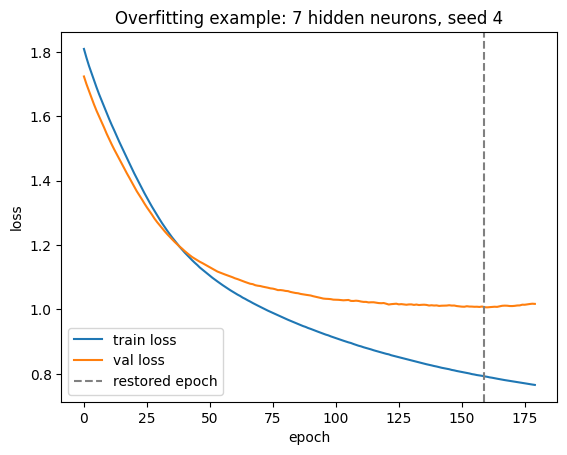

In [ ]:
input_dim = X_train_t.shape[1]
output_dim = int(y_train_t.max().item()) + 1

h_example, seed_example = overfit_runs.iloc[0][["hidden_size", "seed"]]
h_example, seed_example = int(h_example), int(seed_example)

torch.manual_seed(seed_example)
net_example = GrowableNet(input_dim=input_dim, output_dim=output_dim, hidden_dim=h_example)
history_example, best_epoch_example, _ = train_until_stagnation(
    net_example, X_train_t, y_train_t, X_val_t, y_val_t
)

plt.plot(history_example["train_loss"], label="train loss")
plt.plot(history_example["val_loss"], label="val loss")
plt.axvline(best_epoch_example, color="gray", linestyle="--", label="restored epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Overfitting example: {h_example} hidden neurons, seed {seed_example}")
plt.legend()
plt.savefig("glass_overfitting_example.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
print(f"Glass example: train at best epoch = {history_example['train_loss'][best_epoch_example]:.4f}, "
      f"val at best epoch = {history_example['val_loss'][best_epoch_example]:.4f}, "
      f"train final = {history_example['train_loss'][-1]:.4f}, "
      f"val final = {history_example['val_loss'][-1]:.4f}")

Glass example: train at best epoch = 0.7922, val at best epoch = 1.0072, train final = 0.7656, val final = 1.0174


# Test evaluation with the selected architecture:

In [ ]:
BASELINE_HIDDEN_SIZE = 16
baseline_test_results = []

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=9, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    history, best_epoch, best_val_loss = train_until_stagnation(
        net, X_train_t, y_train_t, X_val_t, y_val_t
    )
    test_acc, test_f1 = evaluate(net, X_test_t, y_test_t)

    baseline_test_results.append({
        "seed": seed, "hidden_size": BASELINE_HIDDEN_SIZE,
        "best_epoch": best_epoch + 1,  # human-readable, 1-indexed
        "val_loss": best_val_loss,
        "test_acc": test_acc, "test_macro_f1": test_f1,
    })

baseline_test_df = pd.DataFrame(baseline_test_results)
baseline_test_df

,seed,hidden_size,best_epoch,val_loss,test_acc,test_macro_f1
0,0,16,120,0.959654,0.744186,0.699889
1,1,16,364,0.867860,0.744186,0.766570
2,2,16,328,0.890249,0.744186,0.754503
3,3,16,337,0.932207,0.744186,0.703994
4,4,16,307,0.836004,0.744186,0.766570


In [ ]:
from sklearn.metrics import confusion_matrix

class_names_ordered = [CLASS_NAMES[index_to_label[i]] for i in range(6)]

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=9, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)

    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    cm = confusion_matrix(y_test_t.numpy(), preds, labels=range(6))

    print(f"\n--- seed {seed} ---")
    print(pd.DataFrame(cm, index=class_names_ordered, columns=class_names_ordered))


--- seed 0 ---
               tableware  containers  vehicle_float  headlamps  bldg_float  \
tableware              2           0              0          0           0   
containers             0           3              0          0           0   
vehicle_float          0           0              0          0           2   
headlamps              0           0              0          6           0   
bldg_float             0           0              0          0          10   
bldg_nonfloat          1           0              0          0           3   

               bldg_nonfloat  
tableware                  0  
containers                 0  
vehicle_float              1  
headlamps                  0  
bldg_float                 4  
bldg_nonfloat             11  

--- seed 1 ---
               tableware  containers  vehicle_float  headlamps  bldg_float  \
tableware              2           0              0          0           0   
containers             0           3            

The baseline model reliably separates tableware, containers, and headlamps from the rest, but consistently confuses the three window-glass subtypes (vehicle_float, bldg_float, bldg_nonfloat) with each other, reflecting their chemical similarity. Macro F1 varies by seed (0.70–0.77) despite identical overall accuracy, because which of these three overlapping classes absorbs the error changes with initialization.

In [ ]:
sweep_df.to_csv(data_dir + "baseline_sweep_results.csv", index=False)
summary.to_csv(data_dir + "baseline_sweep_summary.csv", index=False)
baseline_test_df.to_csv(data_dir + "baseline_test_results.csv", index=False)
print("Saved baseline sweep, summary, and final test results to Drive.")

Saved baseline sweep, summary, and final test results to Drive.


# per-instance predictions for the incremental models (needed for the paired test)

In [ ]:
criterion_ni = nn.CrossEntropyLoss(reduction="none")
baseline_instance_records = []

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=9, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)

    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        per_instance_loss = criterion_ni(logits, y_test_t).numpy()
        preds = logits.argmax(dim=1).numpy()

    for i in range(len(y_test_t)):
        baseline_instance_records.append({
            "seed": seed, "instance": i,
            "loss": per_instance_loss[i],
            "correct": int(preds[i] == y_test_t[i].item()),
        })

baseline_instance_df = pd.DataFrame(baseline_instance_records)
baseline_instance_df.to_csv(data_dir + "baseline_test_instance_predictions.csv", index=False)
print("Saved per-instance baseline test predictions.")

Saved per-instance baseline test predictions.


In [ ]:
from sklearn.metrics import recall_score

baseline_recall_runs = []
for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=9, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    baseline_recall_runs.append(recall_score(y_test_t.numpy(), preds, labels=range(6), average=None))

baseline_recall = np.mean(baseline_recall_runs, axis=0)
pd.DataFrame({"class": class_names_ordered, "baseline_recall": baseline_recall}).to_csv(
    data_dir + "baseline_per_class_recall.csv", index=False
)
print("Saved baseline per-class recall.")

Saved baseline per-class recall.
